<a href="https://colab.research.google.com/github/AIML-Dept/Adhisha_Sreedith_1GA23AI002/blob/main/Week_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install qiskit qiskit-aer matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.6 MB/s eta 0:00:00


# **Easy: Implement the oracle for a constant function f(x)=0 and verify the algorithm outputs '0' (constant).**

In [3]:
# Exercise 1: Constant Function f(x) = 0

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Create circuit with:
# qubit 0 = input
# qubit 1 = output/ancilla
# Classical bit = measurement
qc = QuantumCircuit(2, 1)

# Prepare input qubit in |+>
qc.h(0)

# Prepare ancilla in |->
qc.x(1)
qc.h(1)

# Oracle for f(x) = 0
# No operation is required because f(x) is always 0.

# Apply Hadamard to input qubit
qc.h(0)

# Measure input qubit
qc.measure(0, 0)

print(qc.draw())

# Run simulation
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()

counts = result.get_counts()

print("Measurement results:", counts)

# Check result
if '0' in counts and counts['0'] > counts.get('1', 0):
    print("Output: 0 -> Constant function")
else:
    print("Output: 1 -> Balanced function")


     ┌───┐┌───┐┌─┐
q_0: ┤ H ├┤ H ├┤M├
     ├───┤├───┤└╥┘
q_1: ┤ X ├┤ H ├─╫─
     └───┘└───┘ ║ 
c: 1/═══════════╩═
                0 
Measurement results: {'0': 1024}
Output: 0 -> Constant function


# **Medium: Implement the oracle for a balanced function f(x)=x and verify the algorithm outputs '1' (balanced).**

In [4]:
# Exercise 2: Balanced Function f(x) = x

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Create circuit
qc = QuantumCircuit(2, 1)

# Prepare input qubit in |+>
qc.h(0)

# Prepare ancilla in |->
qc.x(1)
qc.h(1)

# Oracle for f(x) = x
# CNOT implements:
# |x,y> -> |x, y XOR x>
qc.cx(0, 1)

# Apply Hadamard to input qubit
qc.h(0)

# Measure input
qc.measure(0, 0)

print(qc.draw())

# Simulate
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()

counts = result.get_counts()

print("Measurement results:", counts)

# Check result
if '1' in counts and counts['1'] > counts.get('0', 0):
    print("Output: 1 -> Balanced function")
else:
    print("Output: 0 -> Constant function")


     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├──────╫─
     └───┘└───┘└───┘      ║ 
c: 1/═════════════════════╩═
                          0 
Measurement results: {'1': 1024}
Output: 1 -> Balanced function


# **Hard: Build a generic oracle-selection function that takes a function type as a parameter and dynamically constructs the correct oracle circuit.**

In [5]:
# Exercise 3: Generic Oracle Selection

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator


def create_oracle(function_type):
    """
    Creates an oracle for a 1-bit Deutsch-Jozsa problem.

    function_type:
        "constant" -> f(x) = 0
        "balanced" -> f(x) = x
    """

    oracle = QuantumCircuit(2, name="Oracle")

    if function_type == "constant":
        # f(x) = 0
        pass

    elif function_type == "balanced":
        # f(x) = x
        oracle.cx(0, 1)

    else:
        raise ValueError(
            "function_type must be 'constant' or 'balanced'"
        )

    return oracle


def deutsch_jozsa(function_type):
    """Run the Deutsch-Jozsa algorithm."""

    qc = QuantumCircuit(2, 1)

    # Prepare input qubit
    qc.h(0)

    # Prepare ancilla in |->
    qc.x(1)
    qc.h(1)

    # Dynamically select oracle
    oracle = create_oracle(function_type)
    qc.compose(oracle, inplace=True)

    # Final Hadamard
    qc.h(0)

    # Measurement
    qc.measure(0, 0)

    return qc


# --------------------------------------------------
# Test 1: Constant
# --------------------------------------------------

qc_constant = deutsch_jozsa("constant")

print("Constant Oracle:")
print(qc_constant.draw())

simulator = AerSimulator()

result = simulator.run(
    qc_constant,
    shots=1024
).result()

counts = result.get_counts()

print("Constant result:", counts)


# --------------------------------------------------
# Test 2: Balanced
# --------------------------------------------------

qc_balanced = deutsch_jozsa("balanced")

print("\nBalanced Oracle:")
print(qc_balanced.draw())

result = simulator.run(
    qc_balanced,
    shots=1024
).result()

counts = result.get_counts()

print("Balanced result:", counts)


Constant Oracle:
     ┌───┐┌───┐┌─┐
q_0: ┤ H ├┤ H ├┤M├
     ├───┤├───┤└╥┘
q_1: ┤ X ├┤ H ├─╫─
     └───┘└───┘ ║ 
c: 1/═══════════╩═
                0 
Constant result: {'0': 1024}

Balanced Oracle:
     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├──────╫─
     └───┘└───┘└───┘      ║ 
c: 1/═════════════════════╩═
                          0 
Balanced result: {'1': 1024}


# **Real-world: Extend the demonstration to explain, with a simple slide/diagram, how phase kickback could conceptually apply to a binary classification decision problem.**

     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├──────╫─
     └───┘└───┘└───┘      ║ 
c: 1/═════════════════════╩═
                          0 
Classification results: {'1': 1024}
Predicted class: Class B (1)


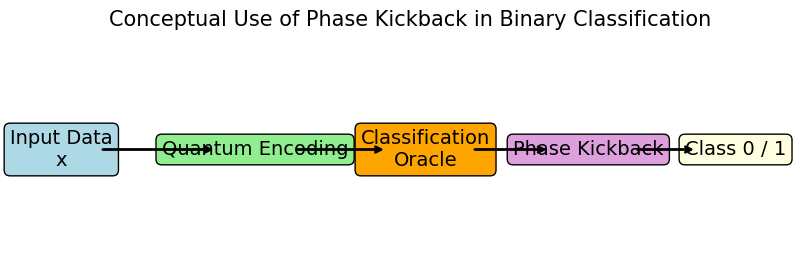

In [6]:
# Exercise 4: Phase Kickback and Binary Classification

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# Create a simple conceptual circuit
qc = QuantumCircuit(2, 1)

# Input represents a data point
qc.h(0)

# Ancilla prepared in |-> state
qc.x(1)
qc.h(1)

# Classification oracle
# Suppose:
# f(x) = x
#
# The CNOT causes phase kickback because
# the second qubit is in the |-> state.
qc.cx(0, 1)

# Interference step
qc.h(0)

# Measure classification result
qc.measure(0, 0)

print(qc.draw())

# Run simulation
simulator = AerSimulator()

result = simulator.run(
    qc,
    shots=1024
).result()

counts = result.get_counts()

print("Classification results:", counts)

# Interpret result
if counts.get('0', 0) > counts.get('1', 0):
    classification = "Class A (0)"
else:
    classification = "Class B (1)"

print("Predicted class:", classification)


# --------------------------------------------------
# Simple conceptual diagram
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 3))

ax.axis("off")

ax.text(
    0.05, 0.5,
    "Input Data\nx",
    ha="center",
    va="center",
    fontsize=14,
    bbox=dict(boxstyle="round", facecolor="lightblue")
)

ax.text(
    0.30, 0.5,
    "Quantum Encoding",
    ha="center",
    va="center",
    fontsize=14,
    bbox=dict(boxstyle="round", facecolor="lightgreen")
)

ax.text(
    0.52, 0.5,
    "Classification\nOracle",
    ha="center",
    va="center",
    fontsize=14,
    bbox=dict(boxstyle="round", facecolor="orange")
)

ax.text(
    0.73, 0.5,
    "Phase Kickback",
    ha="center",
    va="center",
    fontsize=14,
    bbox=dict(boxstyle="round", facecolor="plum")
)

ax.text(
    0.92, 0.5,
    "Class 0 / 1",
    ha="center",
    va="center",
    fontsize=14,
    bbox=dict(boxstyle="round", facecolor="lightyellow")
)

# Arrows
for x1, x2 in [(0.10, 0.25), (0.35, 0.47),
               (0.58, 0.68), (0.79, 0.87)]:

    ax.annotate(
        "",
        xy=(x2, 0.5),
        xytext=(x1, 0.5),
        arrowprops=dict(arrowstyle="->", lw=2)
    )

plt.title(
    "Conceptual Use of Phase Kickback in Binary Classification",
    fontsize=15
)

plt.show()


# **Challenge: Modify the circuit to introduce a deliberate small gate error (imperfect Hadamard) and study how measurement outcome reliability degrades; quantify with a bar chart.**

Error = 0.00 rad | Correct probability = 1.000
Error = 0.02 rad | Correct probability = 1.000
Error = 0.05 rad | Correct probability = 0.999
Error = 0.10 rad | Correct probability = 0.998
Error = 0.20 rad | Correct probability = 0.989
Error = 0.30 rad | Correct probability = 0.984
Error = 0.50 rad | Correct probability = 0.934


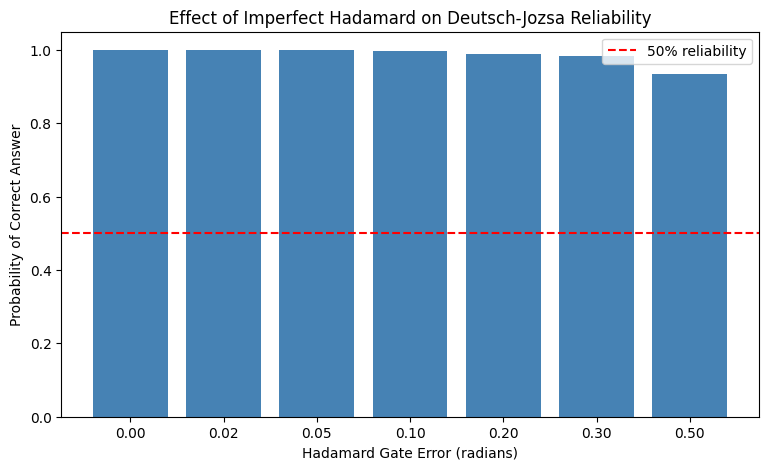

In [7]:
# Exercise 5: Imperfect Hadamard Gate

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt


def imperfect_hadamard(qc, qubit, error):
    """
    Approximate an imperfect Hadamard.

    The ideal H gate is followed by
    a small rotation error.
    """

    qc.h(qubit)

    # Deliberate gate error
    qc.ry(error, qubit)


def run_experiment(error):
    """
    Run Deutsch-Jozsa with an imperfect
    final Hadamard gate.
    """

    qc = QuantumCircuit(2, 1)

    # Prepare input
    qc.h(0)

    # Prepare ancilla in |-> state
    qc.x(1)
    qc.h(1)

    # Balanced oracle f(x) = x
    qc.cx(0, 1)

    # Imperfect final Hadamard
    imperfect_hadamard(qc, 0, error)

    # Measure
    qc.measure(0, 0)

    simulator = AerSimulator()

    result = simulator.run(
        qc,
        shots=1000
    ).result()

    counts = result.get_counts()

    # Probability of correct answer
    correct = counts.get('1', 0) / 1000

    return correct


# --------------------------------------------------
# Test different error sizes
# --------------------------------------------------

errors = [
    0,
    0.02,
    0.05,
    0.10,
    0.20,
    0.30,
    0.50
]

reliability = []

for error in errors:

    probability = run_experiment(error)

    reliability.append(probability)

    print(
        f"Error = {error:.2f} rad | "
        f"Correct probability = {probability:.3f}"
    )


# --------------------------------------------------
# Bar chart
# --------------------------------------------------

plt.figure(figsize=(9, 5))

labels = [
    f"{error:.2f}"
    for error in errors
]

plt.bar(
    labels,
    reliability,
    color="steelblue"
)

plt.xlabel("Hadamard Gate Error (radians)")
plt.ylabel("Probability of Correct Answer")
plt.title(
    "Effect of Imperfect Hadamard on Deutsch-Jozsa Reliability"
)

plt.ylim(0, 1.05)

plt.axhline(
    y=0.5,
    color="red",
    linestyle="--",
    label="50% reliability"
)

plt.legend()

plt.show()
